In [18]:
import importlib
import jax
import jax.numpy as jnp
import pjax
from pjax import nn, optim
import time
import numpy as np
import matplotlib.pyplot as plt
from data import MNISTDataModule

# Reload modules to pick up changes
importlib.reload(pjax.nn.modules)
importlib.reload(pjax.nn)
importlib.reload(pjax)

# Ensure reproducibility
key = jax.random.key(42)

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.6.2
Devices: [CpuDevice(id=0)]


## 1. Define Models with Single Conv Layer

In [19]:
class FftConvModel(nn.Module):
    """Model with a single FftConv2D layer."""
    
    def __init__(self, height, width, in_channels, out_channels, kernel_size):
        super().__init__()
        self.conv = nn.FftConv2D(height, width, in_channels, out_channels, kernel_size)
    
    def __call__(self, x):
        return self.conv(x)


class RegularConvModel(nn.Module):
    """Model with a single Conv2D layer."""
    
    def __init__(self, in_channels, out_channels, kernel_size, padding="SAME"):
        super().__init__()
        self.conv = nn.Conv2D(in_channels, out_channels, kernel_shape=(kernel_size, kernel_size), padding=padding)
    
    def __call__(self, x):
        return self.conv(x)

## 2. Benchmark Functions

In [20]:
def benchmark_forward_pass(model, params, x, num_warmup=1, num_runs=5):
    """Benchmark forward pass timing."""
    
    @jax.jit
    def forward(params, x):
        return model.apply(params, x)
    
    # Warmup runs
    for _ in range(num_warmup):
        _ = forward(params, x)
        jax.block_until_ready(_)
    
    # Timed runs
    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        output = forward(params, x)
        jax.block_until_ready(output)
        end = time.perf_counter()
        times.append(end - start)
    
    return np.mean(times), np.std(times), output


def benchmark_training_step(model, params, x, optimizer, num_warmup=5, num_runs=20):
    """Benchmark training step with loss computation."""
    
    @jax.jit
    def train_step(params, x):
        def loss_fn(params):
            output = model.apply(params, x)
            # MSE reconstruction loss (comparing output to input)
            return pjax.means_squared_error(x, output)
        
        updated_params, loss = optimizer.update(loss_fn, params)
        return updated_params, loss
    
    # Warmup runs
    current_params = params
    for _ in range(num_warmup):
        current_params, loss = train_step(current_params, x)
        jax.block_until_ready(loss)
    
    # Timed runs
    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        current_params, loss = train_step(current_params, x)
        jax.block_until_ready(loss)
        end = time.perf_counter()
        times.append(end - start)
    
    return np.mean(times), np.std(times), float(jnp.abs(loss))

## 3. Run Benchmark on MNIST Data

In [21]:
# Load MNIST data
batch_size = 256
dataset = MNISTDataModule(batch_size=batch_size)
train_data = dataset.train_dataloader()

# Get a sample batch
sample_x, sample_y = next(iter(train_data))
print(f"Original input shape: {sample_x.shape}")

# Scale down to 14x14 using average pooling
from jax.scipy.ndimage import map_coordinates

def resize_images(images, new_height, new_width):
    """Resize images to new dimensions using bilinear interpolation."""
    batch, old_h, old_w, channels = images.shape
    
    # Create coordinate grids for the new size
    y = np.linspace(0, old_h - 1, new_height)
    x = np.linspace(0, old_w - 1, new_width)
    
    # Simple average pooling: reshape and take mean
    # For 28->14, we can use 2x2 pooling
    scale_h = old_h // new_height
    scale_w = old_w // new_width
    
    # Reshape to (batch, new_h, scale_h, new_w, scale_w, channels) and average
    resized = images.reshape(batch, new_height, scale_h, new_width, scale_w, channels)
    resized = resized.mean(axis=(2, 4))
    
    return resized

sample_x = resize_images(sample_x, 14, 14)
print(f"Resized input shape: {sample_x.shape}")

# Model parameters
height, width = 14, 14
in_channels = 1
out_channels = 1
kernel_size = 3

# Initialize models
key1, key2 = jax.random.split(key)

fft_model = FftConvModel(height, width, in_channels, out_channels, kernel_size)
fft_params = fft_model.init(key1)

regular_model = RegularConvModel(in_channels, out_channels, kernel_size)
regular_params = regular_model.init(key2)

print(f"\nFftConv2D params: {jax.tree_util.tree_map(lambda x: x.shape, fft_params)}")
print(f"Conv2D params: {jax.tree_util.tree_map(lambda x: x.shape, regular_params)}")

Original input shape: (256, 28, 28, 1)
Resized input shape: (256, 14, 14, 1)

FftConv2D params: FrozenDict({'conv.kernel': (1, 3, 3, 1)})
Conv2D params: FrozenDict({'conv.linear.weight': (9, 1)})


In [22]:
# Benchmark forward pass
print("=" * 60)
print("FORWARD PASS BENCHMARK")
print("=" * 60)

fft_mean, fft_std, fft_output = benchmark_forward_pass(fft_model, fft_params, sample_x)
print(f"FftConv2D:  {fft_mean*1000:.3f} ± {fft_std*1000:.3f} ms")
print(f"  Output shape: {fft_output.shape}")

regular_mean, regular_std, regular_output = benchmark_forward_pass(regular_model, regular_params, sample_x)
print(f"Conv2D:     {regular_mean*1000:.3f} ± {regular_std*1000:.3f} ms")
print(f"  Output shape: {regular_output.shape}")

speedup = regular_mean / fft_mean if fft_mean > 0 else float('inf')
print(f"\nSpeedup (Conv2D / FftConv2D): {speedup:.2f}x")

FORWARD PASS BENCHMARK
FftConv2D:  1.529 ± 0.076 ms
  Output shape: (256, 14, 14, 2)
Conv2D:     2.247 ± 0.265 ms
  Output shape: (256, 14, 14, 1)

Speedup (Conv2D / FftConv2D): 1.47x


In [23]:
# Benchmark training step
print("=" * 60)
print("TRAINING STEP BENCHMARK")
print("=" * 60)

optimizer = optim.AlternatingProjections(steps_per_update=10)

regular_train_mean, regular_train_std, regular_loss = benchmark_training_step(
    regular_model, regular_params, sample_x, optimizer
)
print(f"Conv2D:     {regular_train_mean*1000:.3f} ± {regular_train_std*1000:.3f} ms (loss: {regular_loss:.6f})")

fft_train_mean, fft_train_std, fft_loss = benchmark_training_step(
    fft_model, fft_params, sample_x, optimizer
)

print(f"FftConv2D:  {fft_train_mean*1000:.3f} ± {fft_train_std*1000:.3f} ms (loss: {fft_loss:.6f})")


train_speedup = regular_train_mean / fft_train_mean if fft_train_mean > 0 else float('inf')
print(f"\nSpeedup (Conv2D / FftConv2D): {train_speedup:.2f}x")

TRAINING STEP BENCHMARK
Using MSE operation
(256, 14, 14, 1) (256, 14, 14, 1)
Conv2D:     115.806 ± 11.997 ms (loss: 0.000024)
Using MSE operation
(256, 14, 14, 1) (256, 14, 14, 2)
FftConv2D:  294.243 ± 21.053 ms (loss: 0.007145)

Speedup (Conv2D / FftConv2D): 0.39x


## 4. Scaling Benchmark: Varying Batch Size

Scaling with batch size:
--------------------------------------------------
Batch   32: FftConv2D =   0.349 ms, Conv2D =   0.528 ms
Batch   64: FftConv2D =   0.386 ms, Conv2D =   0.702 ms
Batch  128: FftConv2D =   1.009 ms, Conv2D =   1.473 ms
Batch  256: FftConv2D =   2.107 ms, Conv2D =   2.785 ms
Batch  512: FftConv2D =   3.050 ms, Conv2D =   5.470 ms
Batch 1024: FftConv2D =   5.534 ms, Conv2D =   9.185 ms


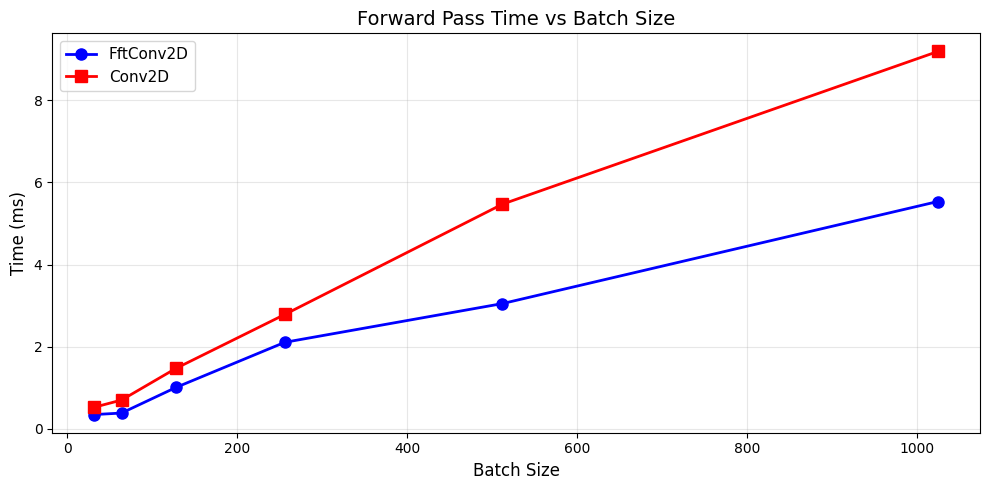

In [24]:
# Test different batch sizes
batch_sizes = [32, 64, 128, 256, 512, 1024]
fft_times = []
regular_times = []

print("Scaling with batch size:")
print("-" * 50)

for bs in batch_sizes:
    # Generate random input with given batch size
    test_x = jax.random.normal(jax.random.key(0), (bs, height, width, in_channels))
    
    fft_mean, fft_std, _ = benchmark_forward_pass(fft_model, fft_params, test_x, num_warmup=3, num_runs=10)
    regular_mean, regular_std, _ = benchmark_forward_pass(regular_model, regular_params, test_x, num_warmup=3, num_runs=10)
    
    fft_times.append(fft_mean * 1000)
    regular_times.append(regular_mean * 1000)
    
    print(f"Batch {bs:4d}: FftConv2D = {fft_mean*1000:7.3f} ms, Conv2D = {regular_mean*1000:7.3f} ms")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, fft_times, 'b-o', label='FftConv2D', linewidth=2, markersize=8)
plt.plot(batch_sizes, regular_times, 'r-s', label='Conv2D', linewidth=2, markersize=8)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Time (ms)', fontsize=12)
plt.title('Forward Pass Time vs Batch Size', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Scaling Benchmark: Varying Kernel Size

Scaling with kernel size:
--------------------------------------------------
Kernel  3x 3: FftConv2D =   1.732 ms, Conv2D =   2.043 ms
Kernel  5x 5: FftConv2D =   1.403 ms, Conv2D =   5.221 ms
Kernel  7x 7: FftConv2D =   1.955 ms, Conv2D =  12.408 ms
Kernel  9x 9: FftConv2D =   1.351 ms, Conv2D =  27.002 ms
Kernel 11x11: FftConv2D =   1.820 ms, Conv2D =  44.560 ms


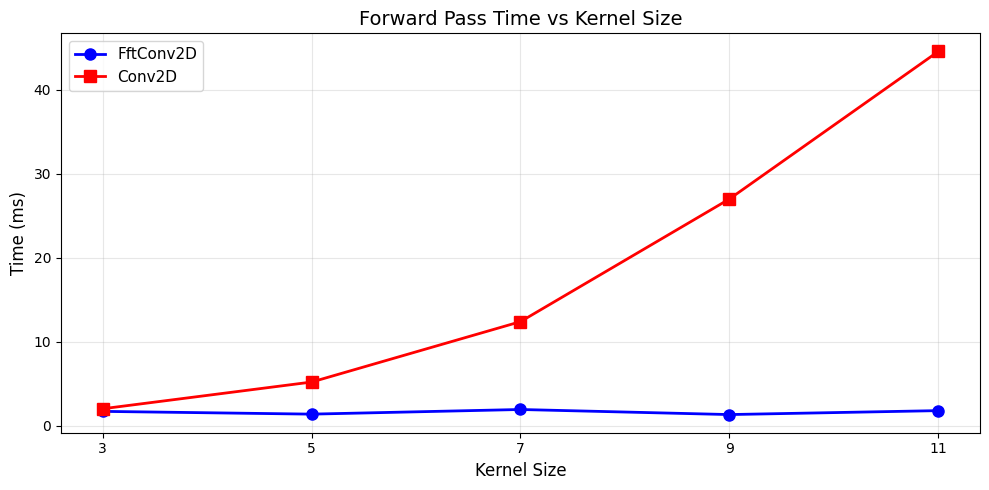

In [25]:
# Test different kernel sizes
kernel_sizes = [3, 5, 7, 9, 11]
fft_times_kernel = []
regular_times_kernel = []
test_batch = 256

print("Scaling with kernel size:")
print("-" * 50)

for ks in kernel_sizes:
    # Generate random input
    test_x = jax.random.normal(jax.random.key(0), (test_batch, height, width, in_channels))
    
    # Create models with different kernel sizes
    fft_model_ks = FftConvModel(height, width, in_channels, out_channels, ks)
    fft_params_ks = fft_model_ks.init(jax.random.key(ks))
    
    regular_model_ks = RegularConvModel(in_channels, out_channels, ks)
    regular_params_ks = regular_model_ks.init(jax.random.key(ks + 100))
    
    fft_mean, fft_std, _ = benchmark_forward_pass(fft_model_ks, fft_params_ks, test_x, num_warmup=3, num_runs=10)
    regular_mean, regular_std, _ = benchmark_forward_pass(regular_model_ks, regular_params_ks, test_x, num_warmup=3, num_runs=10)
    
    fft_times_kernel.append(fft_mean * 1000)
    regular_times_kernel.append(regular_mean * 1000)
    
    print(f"Kernel {ks:2d}x{ks:2d}: FftConv2D = {fft_mean*1000:7.3f} ms, Conv2D = {regular_mean*1000:7.3f} ms")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(kernel_sizes, fft_times_kernel, 'b-o', label='FftConv2D', linewidth=2, markersize=8)
plt.plot(kernel_sizes, regular_times_kernel, 'r-s', label='Conv2D', linewidth=2, markersize=8)
plt.xlabel('Kernel Size', fontsize=12)
plt.ylabel('Time (ms)', fontsize=12)
plt.title('Forward Pass Time vs Kernel Size', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(kernel_sizes)
plt.tight_layout()
plt.show()

## 6. Summary Results

BENCHMARK SUMMARY

Test Configuration:
  - Image size: 14x14
  - Input channels: 1
  - Output channels: 1
  - Default kernel size: 3
  - Default batch size: 256

Forward Pass (batch=256):
  FftConv2D: 1.820 ms
  Conv2D:    44.560 ms
  Speedup:   1.47x (FftConv2D faster)

Training Step (batch=256):
  FftConv2D: 294.243 ms
  Conv2D:    115.806 ms
  Speedup:   0.39x (Conv2D faster)


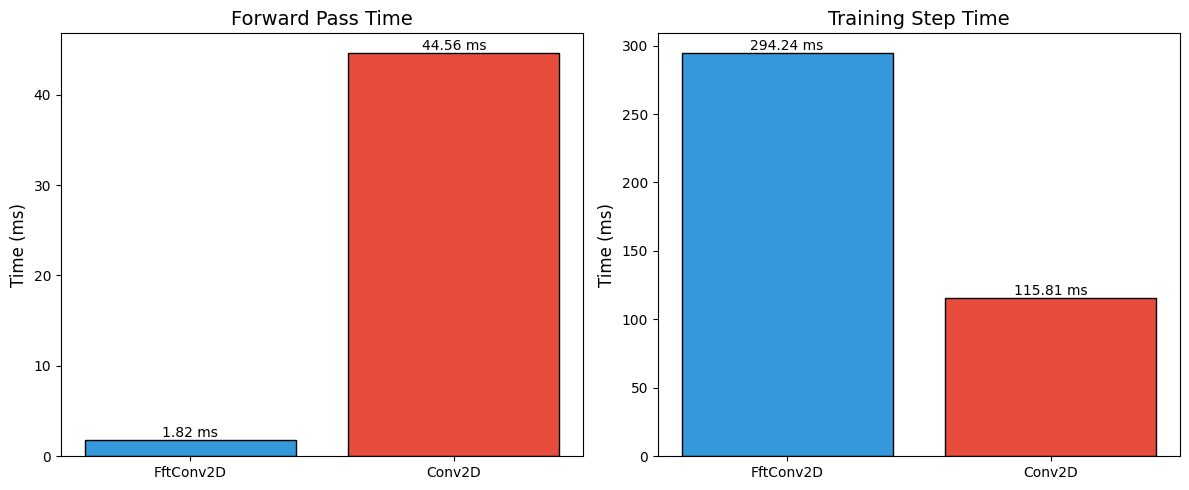

In [26]:
# Create summary table
print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)
print(f"\nTest Configuration:")
print(f"  - Image size: {height}x{width}")
print(f"  - Input channels: {in_channels}")
print(f"  - Output channels: {out_channels}")
print(f"  - Default kernel size: {kernel_size}")
print(f"  - Default batch size: {batch_size}")

print(f"\nForward Pass (batch={batch_size}):")
print(f"  FftConv2D: {fft_mean*1000:.3f} ms")
print(f"  Conv2D:    {regular_mean*1000:.3f} ms")
print(f"  Speedup:   {speedup:.2f}x {'(FftConv2D faster)' if speedup > 1 else '(Conv2D faster)'}")

print(f"\nTraining Step (batch={batch_size}):")
print(f"  FftConv2D: {fft_train_mean*1000:.3f} ms")
print(f"  Conv2D:    {regular_train_mean*1000:.3f} ms")
print(f"  Speedup:   {train_speedup:.2f}x {'(FftConv2D faster)' if train_speedup > 1 else '(Conv2D faster)'}")

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Forward pass comparison
ax1 = axes[0]
methods = ['FftConv2D', 'Conv2D']
forward_times = [fft_mean * 1000, regular_mean * 1000]
colors = ['#3498db', '#e74c3c']
bars1 = ax1.bar(methods, forward_times, color=colors, edgecolor='black')
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.set_title('Forward Pass Time', fontsize=14)
ax1.bar_label(bars1, fmt='%.2f ms', fontsize=10)

# Training step comparison
ax2 = axes[1]
train_times = [fft_train_mean * 1000, regular_train_mean * 1000]
bars2 = ax2.bar(methods, train_times, color=colors, edgecolor='black')
ax2.set_ylabel('Time (ms)', fontsize=12)
ax2.set_title('Training Step Time', fontsize=14)
ax2.bar_label(bars2, fmt='%.2f ms', fontsize=10)

plt.tight_layout()
plt.show()